In [45]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import zscore
from scipy.stats import kstest

In [29]:
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_style("darkgrid")

houses = pd.read_csv("./resource/07_houses_data_outliers.csv")
houses.head()

,id,Area,Precio
0,1,Moonee Valley,"840,000.00"
1,2,Moonee Valley,"730,000.00"
2,3,Moonee Valley,"770,000.00"
3,4,Moonee Valley,"3,396,876.76"
4,5,Moonee Valley,"700,000.00"


In [10]:
f"{houses["Precio"].mean():,.2f}"
f"{houses["Precio"].median():,.2f}"

'957,000.00'

In [11]:
f'{houses["Precio"].mean()/houses["Precio"].median():,.2f}'

'1.42'

In [12]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2639 entries, 0 to 2638
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      2639 non-null   int64  
 1   Area    2639 non-null   object 
 2   Precio  2639 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 62.0+ KB


In [17]:
houses.describe()

,id,Precio
count,"2,639.00","2,639.00"
mean,"1,320.00","1,357,028.23"
std,761.96,"1,098,868.33"
min,1.00,"145,000.00"
25%,660.50,"655,000.00"
50%,"1,320.00","957,000.00"
75%,"1,979.50","1,650,000.00"
max,"2,639.00","8,000,000.00"


In [20]:
groo_area_houses = houses.groupby("Area")
groo_area_houses["Precio"].describe()

,count,mean,std,min,25%,50%,75%,max
Area,,,,,,,,
Boroondara,625.00,"2,137,082.76","1,494,338.38","275,000.00","1,150,000.00","1,800,000.00","2,550,000.00","8,000,000.00"
Darebin,482.00,"1,158,626.84","853,457.76","216,000.00","606,250.00","885,000.00","1,263,750.00","3,631,504.34"
Melbourne,279.00,"1,230,859.15","1,044,093.67","275,000.00","568,250.00","800,000.00","1,350,000.00","4,525,000.00"
Moonee Valley,553.00,"1,173,741.71","764,004.69","222,000.00","712,000.00","953,000.00","1,385,000.00","3,798,510.66"
Moreland,700.00,"992,248.23","656,144.88","145,000.00","600,000.00","792,500.00","1,083,750.00","3,196,082.21"


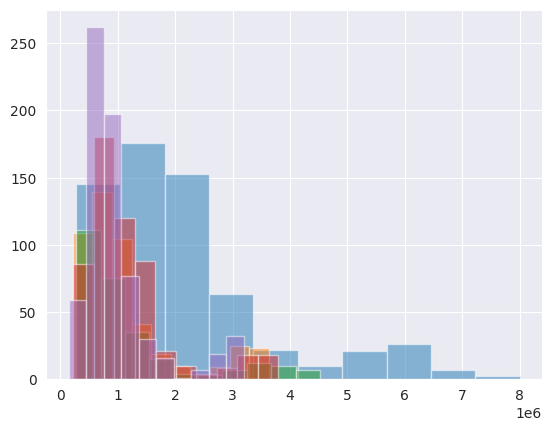

In [30]:
groo_area_houses["Precio"].hist(alpha=0.5)
plt.show()

In [ ]:
stat, p = kstest(houses["Precio"], 'norm', args=(houses["Precio"].mean(), houses["Precio"].std()))

if p > 0.05:
    print("No se rechaza H0: los datos siguen una distribución normal.")
else:
    print("Se rechaza H0: los datos NO siguen una distribución normal.")

Se rechaza H0: los datos NO siguen una distribución normal.


In [24]:
houses["Precio"].kurtosis()

np.float64(5.693789438745391)

In [25]:
houses["Precio"].skew()

np.float64(2.1619835764483364)

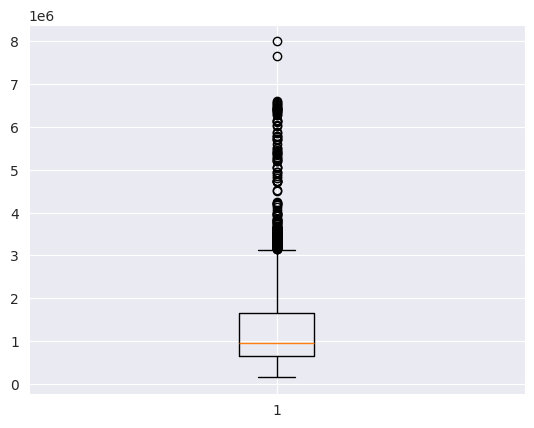

In [31]:
plt.boxplot(houses["Precio"])

plt.show()

In [32]:
zcore_houses_precio = zscore(houses["Precio"])

abs_zcore_houses_precio = np.abs(zcore_houses_precio)
abs_zcore_houses_precio

array([0.47059889, 0.57072084, 0.53431286, ..., 0.11647986, 0.62351242,
       0.42417871], shape=(2639,))

In [40]:
houses["outlier_zscore"] = (abs_zcore_houses_precio > 3)*1
houses.head()

,id,Area,Precio,outlier_zscore
0,1,Moonee Valley,"840,000.00",0
1,2,Moonee Valley,"730,000.00",0
2,3,Moonee Valley,"770,000.00",0
3,4,Moonee Valley,"3,396,876.76",0
4,5,Moonee Valley,"700,000.00",0


In [41]:
zscore_group=houses.groupby('Area').agg(
    Casas=('id', 'count'),
    Outlier=('outlier_zscore', 'sum')
).reset_index()

zscore_group['Ratio_out']=zscore_group['Outlier']/zscore_group['Casas']

zscore_group

,Area,Casas,Outlier,Ratio_out
0,Boroondara,625,64,0.10
1,Darebin,482,0,0.00
2,Melbourne,279,0,0.00
3,Moonee Valley,553,0,0.00
4,Moreland,700,0,0.00


In [42]:
houses.groupby(['Area','outlier_zscore']).agg(
    Casas=('id', 'count'),
    Precio_Promedio=('Precio', 'mean')
).reset_index()

,Area,outlier_zscore,Casas,Precio_Promedio
0,Boroondara,0,561,"1,721,240.00"
1,Boroondara,1,64,"5,782,204.47"
2,Darebin,0,482,"1,158,626.84"
3,Melbourne,0,279,"1,230,859.15"
4,Moonee Valley,0,553,"1,173,741.71"
5,Moreland,0,700,"992,248.23"


In [43]:
# Calcular percentiles
q75 = houses['Precio'].quantile(0.75)
q25 = houses['Precio'].quantile(0.25)

# Obtener IQR
iqr = q75 - q25

# thresholds
upper = q75 + (1.5 * iqr)
lower = q25 - (1.5 * iqr)

houses['outlier_iqr']=((houses['Precio'] < lower) | (houses['Precio'] > upper))*1
houses.head()

,id,Area,Precio,outlier_zscore,outlier_iqr
0,1,Moonee Valley,"840,000.00",0,0
1,2,Moonee Valley,"730,000.00",0,0
2,3,Moonee Valley,"770,000.00",0,0
3,4,Moonee Valley,"3,396,876.76",0,1
4,5,Moonee Valley,"700,000.00",0,0


In [44]:
iqr_group=houses.groupby('Area').agg(
    Casas=('id', 'count'),
    Outlier=('outlier_iqr', 'sum'),
).reset_index()

iqr_group['Ratio_out']=iqr_group['Outlier']/iqr_group['Casas']

iqr_group

,Area,Casas,Outlier,Ratio_out
0,Boroondara,625,104,0.17
1,Darebin,482,33,0.07
2,Melbourne,279,32,0.11
3,Moonee Valley,553,32,0.06
4,Moreland,700,7,0.01


### Ejercicios

In [54]:
# Calcular percentiles
q75 = houses['Precio'].quantile(0.75)
q25 = houses['Precio'].quantile(0.25)

# Obtener IQR
iqr = q75 - q25

# thresholds
upper_extreme = q75 + (3 * iqr)
lower_extreme = q25 - (3 * iqr)

houses['extreme_iqr']=((houses['Precio'] < lower_extreme) | (houses['Precio'] > upper_extreme))*1
houses.head()

,id,Area,Precio,outlier_zscore,outlier_iqr,extreme_iqr
0,1,Moonee Valley,"840,000.00",0,0,0
1,2,Moonee Valley,"730,000.00",0,0,0
2,3,Moonee Valley,"770,000.00",0,0,0
3,4,Moonee Valley,"3,396,876.76",0,0,0
4,5,Moonee Valley,"700,000.00",0,0,0


In [56]:
iqr_group_extreme=houses.groupby('Area').agg(
    Casas=('id', 'count'),
    Outlier=('extreme_iqr', 'sum'),
).reset_index()

iqr_group_extreme['Ratio_ext']=iqr_group_extreme['Outlier']/iqr_group_extreme['Casas']

iqr_group_extreme

,Area,Casas,Outlier,Ratio_ext
0,Boroondara,625,64,0.10
1,Darebin,482,0,0.00
2,Melbourne,279,0,0.00
3,Moonee Valley,553,0,0.00
4,Moreland,700,0,0.00


In [ ]:
filtro_extremo = houses["extreme_iqr"] > 0

promedio_extremo = houses[filtro_extremo]["Precio"].mean()
promedio_no_extremo = houses[~filtro_extremo]["Precio"].mean()

print(f"""
    media extremo    {promedio_extremo}
    media no extremo {promedio_no_extremo}
    """)


    media extremo    5782204.47396875
    media no extremo 1247043.2635565049
    


### **2.1 Análisis y Estrategia**

### **Comparativa en el uso de z-score e IQR**
Ambos métodos tienen sus ventajas, pero depende del tipo de datos. Si los datos siguen una distribución más o menos normal, el **Z-score** es una opción sólida porque mide cuántas desviaciones estándar se aleja un punto de la media. En cambio, si los datos tienen valores extremos o una distribución no normal, el **IQR (rango intercuartílico)** es mejor porque se basa en la mediana y no se ve afectado por outliers extremos.  

### **¿Qué método gráfico preferirías (histogramas o boxplots)? ¿Cuándo y por qué?**
Depende de lo que quiera analizar.  
- Si quiero ver la distribución general de los datos y cómo se agrupan los valores, prefiero **un histograma**.  
- Si quiero identificar valores atípicos y ver la dispersión de los datos, prefiero **un boxplot**, porque me muestra de un vistazo dónde están los outliers.  

Si tengo que elegir uno para detectar outliers, me quedo con el **boxplot**, ya que deja en claro cuáles puntos están fuera del rango esperado.  

### **¿Qué modelo de detección de outliers sería más adecuado para el conjunto de datos y por qué?**
En la mayoría de los casos reales, el **IQR** es más confiable, porque los datos raramente siguen una distribución normal perfecta, commo es el caso de los datos que estuvimos trabajando por tanto el metodo de **boxplot** es el más adecuado a mi parecer.

### **¿Qué estrategia debería seguir Elite Properties?**
Si Elite Properties quiere tomar decisiones con base en los datos, lo primero es limpiar los outliers que sean errores obvios en la captura de datos. Luego, pueden analizar si los valores atípicos tienen algún significado importante.
Si, por ejemplo, están viendo precios de propiedades y hay valores extremadamente altos, podrían representar casas de lujo, no errores. En ese caso, podrían segmentar su análisis en distintos rangos de precios en lugar de eliminarlos.  

### **¿Qué información adicional crees que es importante analizar para fortalecer la estrategia?**
Para tomar mejores decisiones, sería útil analizar:  
- **Tendencias de mercado:** Ver cómo han cambiado los precios en el tiempo.  
- **Factores externos:** Ubicación, demanda, crecimiento económico en la zona.  
- **Segmentación de clientes:** Entender si los outliers corresponden a nichos específicos de clientes o propiedades.  
- **Distribución de precios por tipo de propiedad:** Para ver si hay patrones que expliquen los valores atípicos.  

En resumen, no solo eliminar outliers, sino entenderlos y ver si aportan información valiosa.  